In [15]:
%load_ext autoreload
%autoreload 2

import logging

from benchmarks.run_methods import run_sampling
from causalchange.causal_change import CausalChange
from causalchange.config.benchmark_config import SingleDataConfig
from causalchange.config.cc_types import DataMode, GraphSearch, ScoreType

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
lg = logging.basicConfig(level=logging.INFO)

cfg_data = {
    "setting": "single",
    "n_nodes": 5,
    "edge_prob": 0.4,
    "n_samples": 1000,
    "nonlinearity": "tanh",
}
cfg_data = SingleDataConfig.model_validate(cfg_data)
df, true_g = run_sampling(cfg_data)

In [17]:
est = CausalChange(
    data_mode=DataMode.IID,
    graph_search=GraphSearch.TOPIC,
    score_type=ScoreType.GAM,
    vb=2,
    lg=lg,
)
dag = est.fit(df)

[('X4', 'X0'), ('X4', 'X2')]
[('X2', 'X1'), ('X4', 'X0'), ('X4', 'X2')]


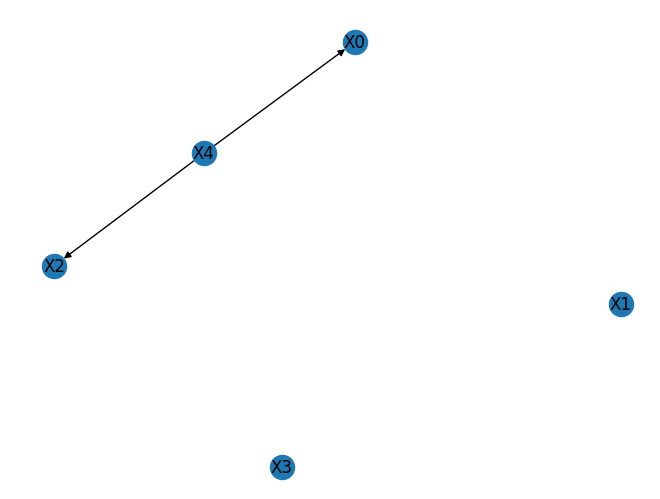

In [18]:
import networkx as nx

nx.draw(dag, with_labels=True)
print(dag.edges)
print(true_g.edges)